<a href="https://colab.research.google.com/github/PeterykSong/Document/blob/main/HW1_20250319.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

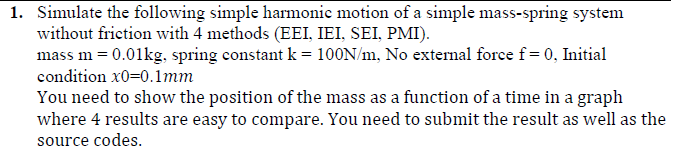

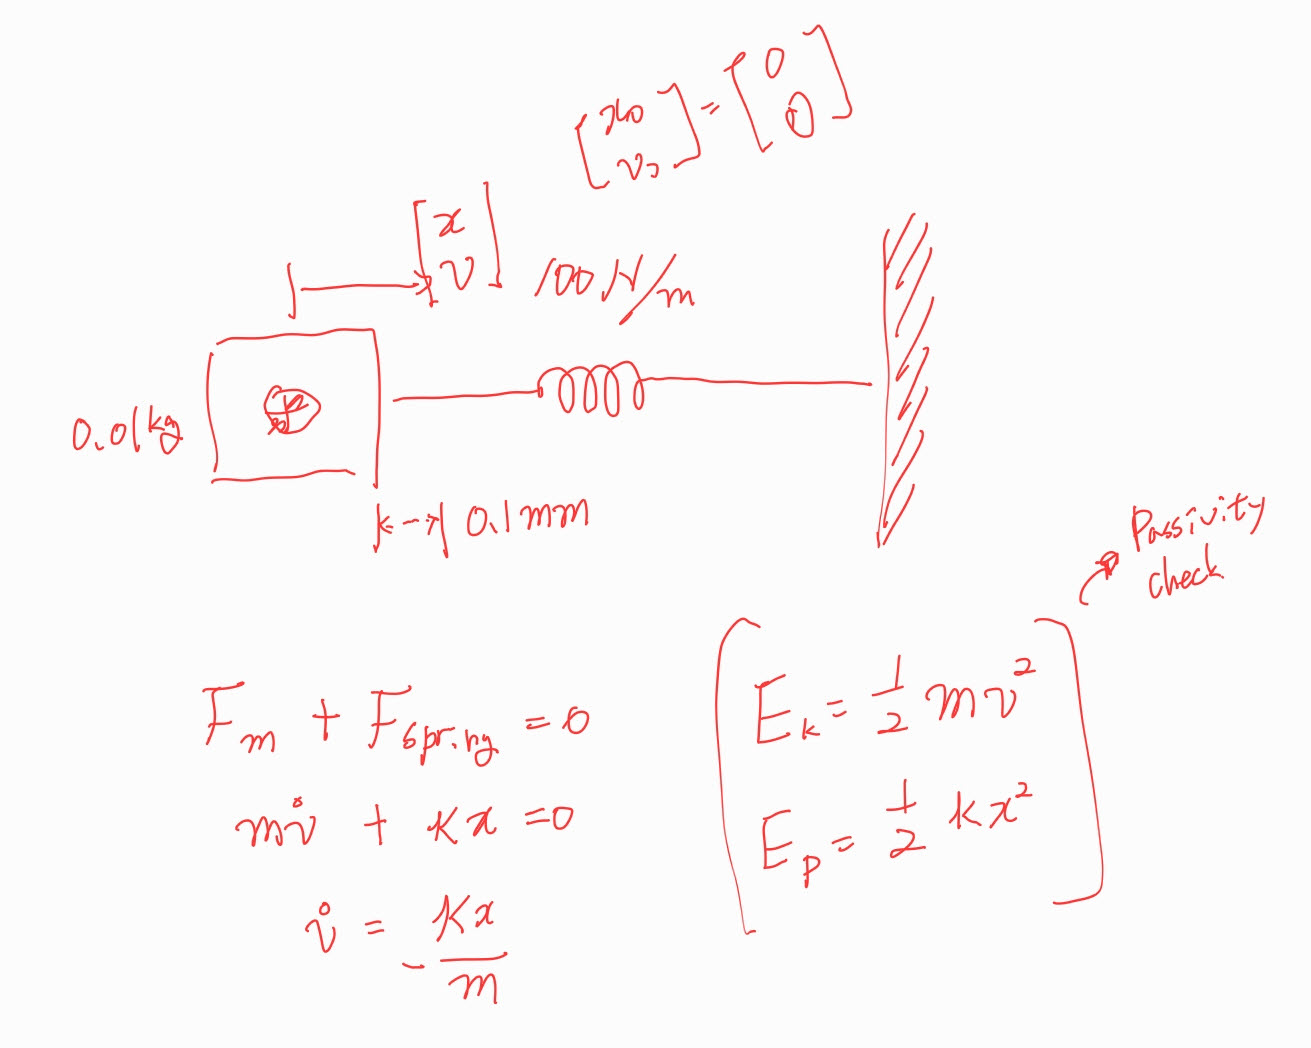

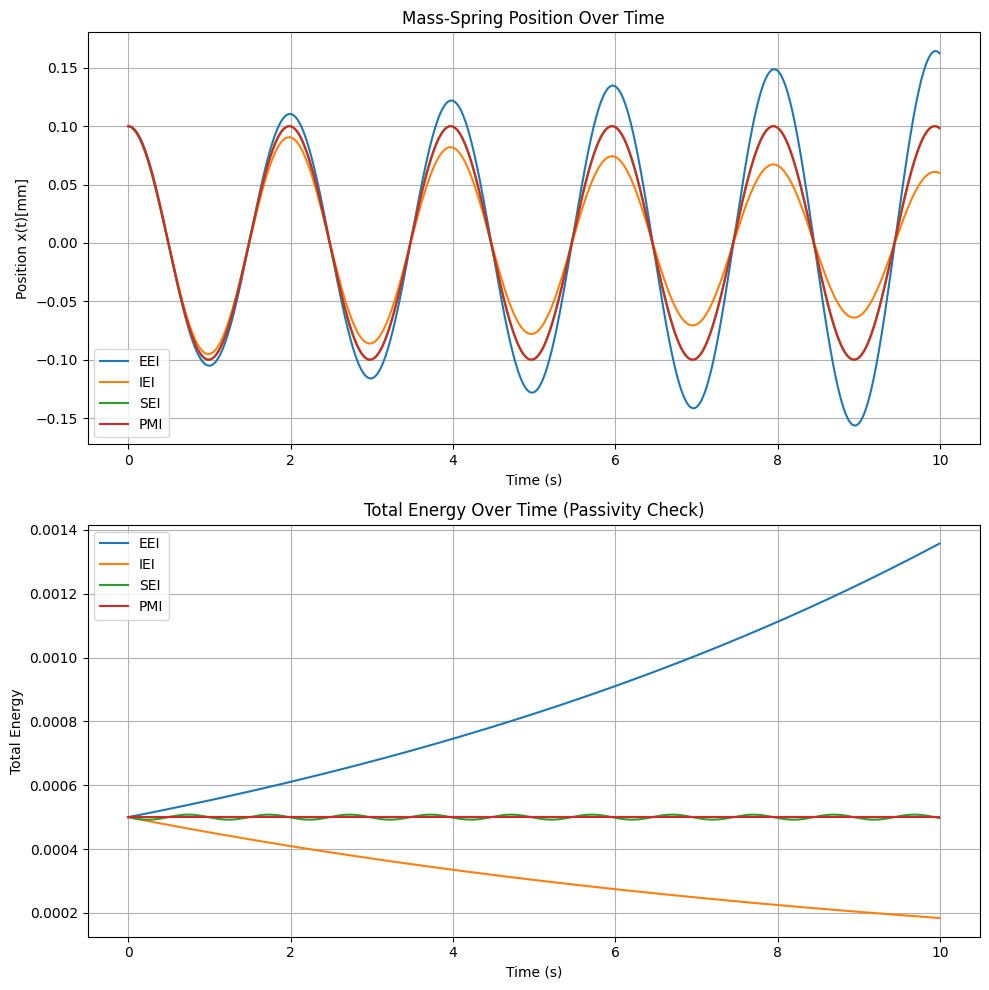

In [18]:
import numpy as np
import matplotlib.pyplot as plt

def mass_spring_system(x, v, k, m):
    """질량-스프링 시스템의 미분 방정식"""
    dxdt = v
    dvdt = - (k * x / m )
    return dxdt, dvdt

def compute_energy(x, v, k, m):
    """상태 에너지 계산"""
    kinetic = 0.5 * m * v**2
    potential = 0.5 * k * x**2
    return kinetic + potential

def EEI(x, v, k, m, dt):
    """Explicit Euler Integration (EEI)"""
    dxdt, dvdt = mass_spring_system(x, v, k, m)
    x_new = x + dt * dxdt
    v_new = v + dt * dvdt
    return x_new, v_new

def IEI(x, v, k, m, dt):
    """Implicit Euler Integration (IEI)"""
    x_new = (x + dt * v) / (1 + dt**2 * (k/m))
    v_new = v - dt * (k/m) * x_new
    return x_new, v_new

def SEI(x, v, k, m, dt):
    """Semi-Implicit Euler Integration (SEI)"""
    v_new = v - dt * (k/m) * x
    x_new = x + dt * v_new
    return x_new, v_new

def PMI(x, v, k, m, dt, tol=1e-6, max_iter=10):
    """Passive Midpoint Integration (PMI)"""
    x_next, v_next = x, v

    for _ in range(max_iter):
        x_mid = (x + x_next) / 2
        v_mid = (v + v_next) / 2
        dxdt, dvdt = mass_spring_system(x_mid, v_mid, k, m)
        x_new = x + dt * dxdt
        v_new = v + dt * dvdt

        if abs(x_new - x_next) < tol and abs(v_new - v_next) < tol:
            break

        x_next, v_next = x_new, v_new

    return x_next, v_next

def simulate(method, x0, v0, k, m, dt, t_end):
    """주어진 수치 방법을 사용하여 질량-스프링 시스템 시뮬레이션 수행"""
    t_values = np.arange(0, t_end, dt)
    x_values, v_values, energy_values = np.zeros_like(t_values), np.zeros_like(t_values), np.zeros_like(t_values)
    x, v = x0, v0
    for i, t in enumerate(t_values):
        x_values[i] = x
        v_values[i] = v
        energy_values[i] = compute_energy(x, v, k, m)
        x, v = method(x, v, k, m, dt)
    return t_values, x_values, energy_values


def plot_results(x0, v0, k, m, dt, t_end):
    methods = {"EEI": EEI, "IEI": IEI, "SEI": SEI, "PMI": PMI}

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10))

    for name, method in methods.items():
        t, x_vals, energy_vals = simulate(method, x0, v0, k, m, dt, t_end)
        ax1.plot(t, x_vals, label=name)
        ax2.plot(t, energy_vals, label=name)

    ax1.set_xlabel("Time (s)")
    ax1.set_ylabel("Position x(t)[mm]")
    ax1.set_title("Mass-Spring Position Over Time")
    ax1.grid()
    ax1.legend()

    ax2.set_xlabel("Time (s)")
    ax2.set_ylabel("Total Energy")
    ax2.set_title("Total Energy Over Time (Passivity Check)")
    ax2.grid()
    ax2.legend()

    plt.tight_layout()
    plt.show()


# 초기 조건 설정
x0 = 0.1  # 0.1 mm
v0 = 0.0      # 초기 속도
k = 0.10     # 스프링 상수 [N/mm] 단위변경
m = 0.01      # 질량 [kg]
dt, t_end = 0.01, 10  # 시간 간격과 시뮬레이션 시간

plot_results(x0, v0, k, m, dt, t_end)

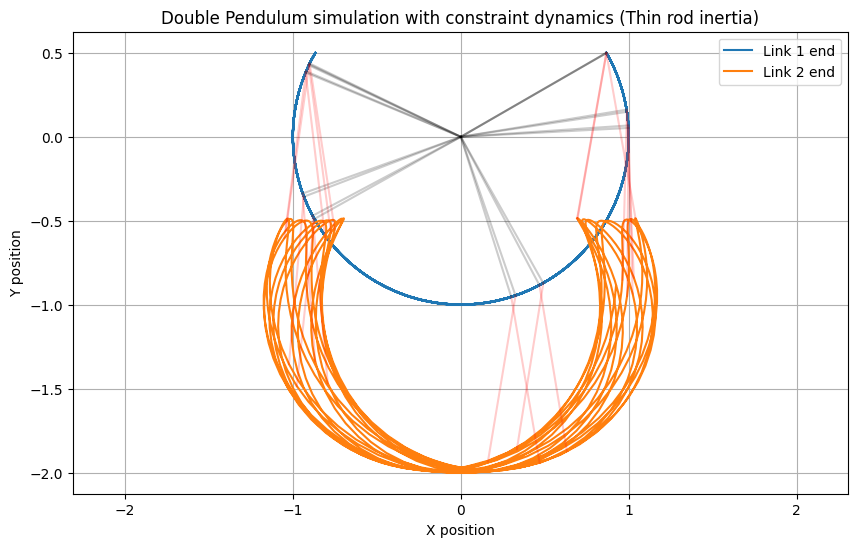

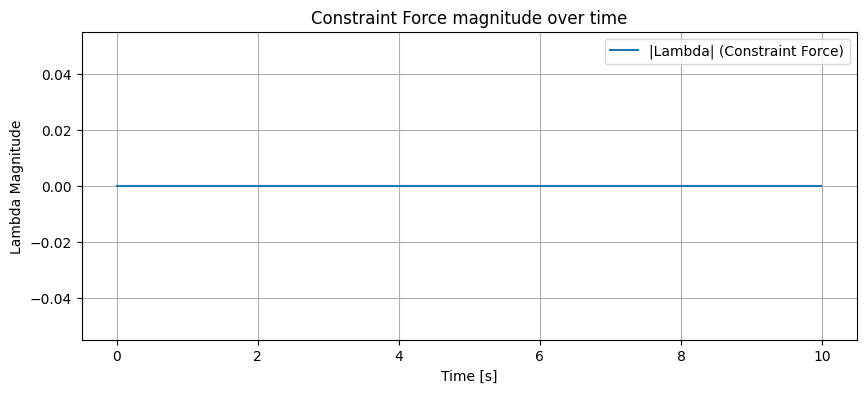

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# 시뮬레이션 파라미터 (Thin rod 가정 시: Inertia = (1/12) * m * L^2)
m1, m2 = 1.0, 1.0
l1, l2 = 1.0, 1.0
g = 9.81
Inertia1, Inertia2 = (m1 * l1 ** 2) / 12.0, (m2 * l2 ** 2) / 12.0  # Thin rod 가정

# 시간 설정
dt = 0.01
total_time = 10
steps = int(total_time / dt)

# 초기 상태 설정
theta1, theta2 = np.radians(120), np.radians(-10)
omega1, omega2 = 0.0, 0.0

# 데이터 저장용
hist_p1, hist_p2 = [], []
hist_lambda_norm = []
hist_link_positions = []

for step in range(steps):
    # 질량 및 외력 행렬
    M = np.diag([Inertia1, Inertia2])
    F_ext = np.array([
        -m1 * g * l1 / 2 * np.sin(theta1),
        -m2 * g * l2 / 2 * np.sin(theta2)
    ])

    # 제약식 Jacobian 계산
    J = np.array([
        [-l1 * np.cos(theta1), -l2 * np.cos(theta2)],
        [-l1 * np.sin(theta1), -l2 * np.sin(theta2)]
    ])

    # p1은 항상 링크 1 끝 (회전점 기준으로 길이 l1 유지)
    p1 = np.array([l1 * np.sin(theta1), -l1 * np.cos(theta1)])
    p2 = p1 + np.array([l2 * np.sin(theta2), -l2 * np.cos(theta2)])

    # 위치 오류 벡터
    C = p2 - (p1 + np.array([0.0, 0.0]))

    # 속도 벡터
    V = np.array([omega1, omega2])

    # lambda(제약력) 계산
    J_inv = np.linalg.pinv(J @ np.linalg.inv(M) @ J.T)
    b = - (J @ (V + dt * np.linalg.inv(M) @ F_ext)) / dt - (0.2 * C / dt)
    lambd = J_inv @ b * 0

    # 속도 업데이트
    V_next = V + dt * (np.linalg.inv(M) @ (F_ext + J.T @ lambd))
    omega1, omega2 = V_next

    # 각도 업데이트
    theta1 += omega1 * dt
    theta2 += omega2 * dt

    # 위치 및 lambda 기록
    hist_p1.append(p1.copy())
    hist_p2.append(p2.copy())
    hist_lambda_norm.append(np.linalg.norm(lambd))
    hist_link_positions.append((p1.copy(), p2.copy()))

# 결과 시각화
hist_p1 = np.array(hist_p1)
hist_p2 = np.array(hist_p2)

plt.figure(figsize=(10, 6))
plt.plot(hist_p1[:, 0], hist_p1[:, 1], label='Link 1 end')
plt.plot(hist_p2[:, 0], hist_p2[:, 1], label='Link 2 end')

# 중간중간에 링크 시각화
interval = steps // 20
for i in range(0, steps, interval):
    p1, p2 = hist_link_positions[i]
    plt.plot([0, p1[0]], [0, p1[1]], 'k-', alpha=0.2)  # Link 1
    plt.plot([p1[0], p2[0]], [p1[1], p2[1]], 'r-', alpha=0.2)  # Link 2

plt.xlabel('X position')
plt.ylabel('Y position')
plt.legend()
plt.grid()
plt.title('Double Pendulum simulation with constraint dynamics (Thin rod inertia)')
plt.axis('equal')  # x, y 스케일 동일하게 맞춤
plt.show()

# Lambda(제약력) 값 시각화
plt.figure(figsize=(10, 4))
plt.plot(np.arange(steps) * dt, hist_lambda_norm, label='|Lambda| (Constraint Force)')
plt.xlabel('Time [s]')
plt.ylabel('Lambda Magnitude')
plt.grid()
plt.title('Constraint Force magnitude over time')
plt.legend()
plt.show()
